# Introducción y la Intuición del Gradiente Descendiente

En la sesión anterior vimos la solución analítica de Mínimos Cuadrados Ordinarios (OLS):$$\beta = (X^T X)^{-1} X^T y$$El problema en el mundo real: Esta es una fórmula cerrada, pero computacionalmente frágil. Invertir una matriz, $(X^T X)^{-1}$, tiene una complejidad de $O(n^3)$. Si tu empresa tiene una base de datos con millones de clientes o miles de variables (features), el cómputo literal explota y la máquina se queda sin memoria.

Ahora vamos a aprender cómo se resuelve esto en la industria. Vamos a aprender el algoritmo que está en el corazón de todos los modelos modernos de Machine Learning y Deep Learning (incluyendo los LLMs): El Gradiente Descendiente.

## La topología de la superficie de la función de costo

En lugar de buscar la solución exacta en un solo paso, definimos el Error Cuadrático Medio (MSE) como una función de costo $J(\theta)$ parametrizada por los pesos del modelo. Para la regresión lineal, esta función de costo describe un hiperparaboloide estrictamente convexo en el espacio de parámetros.La estrategia de optimización consiste en:
1. Inicializar los parámetros $\theta$ en un punto arbitrario del espacio.
2. Calcular el vector gradiente $\nabla J(\theta)$ evaluado en ese punto. 
3. El gradiente apunta siempre en la dirección de máximo crecimiento de la función.
4. Actualizar los parámetros moviéndose en la dirección opuesta al vector gradiente.Iterar hasta alcanzar un criterio de convergencia donde $\nabla J(\theta) \approx 0$.

## Formalización de la Regla de Actualización
La iteración matemática que define el algoritmo actualiza cada parámetro simultáneamente mediante la siguiente regla:
$$\theta_j := \theta_j - \alpha \cdot \frac{\partial J}{\partial \theta_j}$$
Donde:
* $\theta_j$ representa el parámetro en ajuste.
* $\alpha$ es la Tasa de Aprendizaje o Learning Rate, un hiperparámetro escalar que modula la magnitud del paso de actualización.
* $\frac{\partial J}{\partial \theta_j}$ es la derivada parcial de la función de costo.

Para el caso específico del MSE, la derivación parcial respecto al intercepto $\beta_0$ y la pendiente $\beta_1$ resulta en:$$\frac{\partial J}{\partial \beta_0} = -\frac{1}{n}\sum(y_i - \hat{y}_i) \qquad \frac{\partial J}{\partial \beta_1} = -\frac{1}{n}\sum x_i(y_i - \hat{y}_i)$$

In [2]:
# Importar las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
# Implementación del Algoritmo de Optimización
def batch_gradient_descent(X, y, learning_rate=0.1, n_epochs=100):
    n_samples = len(y)
    beta0 = 0.0  # Inicialización arbitraria
    beta1 = 0.0
    history = [] # Registro de la función de costo

    for epoch in range(n_epochs):
        # A. Vector de predicciones
        y_pred = beta0 + beta1 * X

        # B. Cálculo de residuales
        error = y - y_pred

        # C. Cálculo del gradiente sobre el batch completo
        grad_beta0 = -2/n_samples * np.sum(error)
        grad_beta1 = -2/n_samples * np.sum(X * error)

        # D. Actualización paramétrica
        beta0 = beta0 - learning_rate * grad_beta0
        beta1 = beta1 - learning_rate * grad_beta1

        # Registro del Error Cuadrático Medio
        mse = np.mean(error**2)
        history.append(mse)

    return beta0, beta1, history

In [4]:
# Generación de un dataset de prueba
np.random.seed(42)
n = 80
X_demo = 2 * np.random.rand(n)
# Relación subyacente: y = 3 + 1.8x + ruido gaussiano
y_demo = 3 + 1.8 * X_demo + np.random.randn(n) * 0.5 

# Ejecución del modelo
b0_final, b1_final, cost_history = batch_gradient_descent(X_demo, y_demo, learning_rate=0.1, n_epochs=150)

print("Resultados de la optimización:")
print(f"beta_0 calculado : {b0_final:.4f}  (Valor teórico ≈ 3.0)")
print(f"beta_1 calculado : {b1_final:.4f}  (Valor teórico ≈ 1.8)")

Resultados de la optimización:
beta_0 calculado : 2.8877  (Valor teórico ≈ 3.0)
beta_1 calculado : 1.9148  (Valor teórico ≈ 1.8)


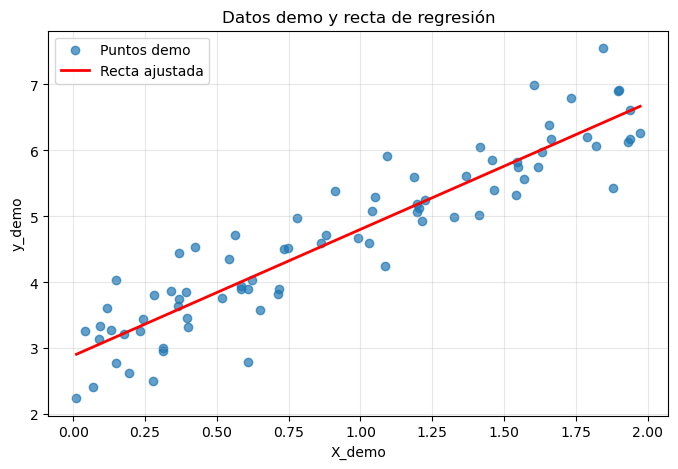

In [5]:
# Gráfica de los puntos demo y la recta ajustada
plt.figure(figsize=(8, 5))
plt.scatter(X_demo, y_demo, alpha=0.7, label="Puntos demo")

x_line = np.linspace(X_demo.min(), X_demo.max(), 200)
y_line = b0_final + b1_final * x_line
plt.plot(x_line, y_line, color="red", linewidth=2, label="Recta ajustada")

plt.title("Datos demo y recta de regresión")
plt.xlabel("X_demo")
plt.ylabel("y_demo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Escalabilidad y Variantes Estocásticas del Gradiente Descendiente

En la sección anterior definimos la actualización paramétrica calculando el gradiente sobre el conjunto de datos completo (Batch). Si la matriz de diseño $X$ tiene millones de observaciones, evaluar $\frac{1}{N} \sum_{i=1}^N \nabla J_i(\theta)$ para dar un solo paso de actualización resulta prohibitivo en términos de memoria RAM y tiempo de cómputo. Para escalar el algoritmo a conjuntos de datos masivos, la optimización moderna recurre a aproximaciones estocásticas del gradiente.

### Formulación de las Tres Variantes

La diferencia fundamental entre las arquitecturas de optimización radica en la cardinalidad del subconjunto de datos utilizado para estimar el vector gradiente en cada iteración.

* ***Batch Gradient Descent***: Utiliza el conjunto de datos completo ($N$ muestras). Produce una estimación determinista y exacta del gradiente de la función de costo empírica. Su convergencia es topológicamente suave, pero el costo computacional por época es máximo.

* ***Stochastic Gradient Descent (SGD)***: Aproxima el gradiente evaluando una única observación aleatoria $i$ en cada paso, tal que $\nabla J(\theta) \approx \nabla J_i(\theta)$. Esta restricción introduce una alta varianza en la trayectoria de optimización. Aunque la convergencia es numéricamente ruidosa, esta estocasticidad actúa como un mecanismo de regularización implícita y permite al modelo escapar de mínimos locales subóptimos en superficies de costo no convexas.

* ***Mini-Batch Gradient Descent***: Representa la solución de compromiso óptima. Aproxima el gradiente utilizando un lote de tamaño $k$ (usualmente potencias de 2, como 32, 64 o 128) donde $\nabla J(\theta) \approx \frac{1}{k} \sum_{i=m}^{m+k} \nabla J_i(\theta)$. Minimiza la varianza paramétrica del SGD mientras maximiza la eficiencia computacional mediante la vectorización de hardware en arquitecturas de procesamiento paralelo.

In [6]:
# Generación de un dataset de mayor volumen para evidenciar latencia
np.random.seed(42)
n_large = 5000
X_large = 3 * np.random.rand(n_large)
y_large = 2.5 + 1.5 * X_large + np.random.randn(n_large) * 0.6

def gd_variants(X, y, variant='batch', learning_rate=0.05, n_epochs=60, batch_size=32):
    n = len(y)
    beta0, beta1 = 0.0, 0.0
    cost_per_epoch = []
    
    for epoch in range(n_epochs):
        # Permutación aleatoria para garantizar independencia estadística en los lotes
        idx = np.random.permutation(n)
        X_shuf, y_shuf = X[idx], y[idx]
        
        if variant == 'batch':
            batches = [(X_shuf, y_shuf)]
        elif variant == 'stochastic':
            batches = [(X_shuf[i:i+1], y_shuf[i:i+1]) for i in range(n)]
        elif variant == 'minibatch':
            batches = [(X_shuf[i:i+batch_size], y_shuf[i:i+batch_size]) for i in range(0, n, batch_size)]
            
        for X_batch, y_batch in batches:
            nb = len(y_batch)
            y_pred = beta0 + beta1 * X_batch
            error = y_batch - y_pred
            
            # Cálculo del gradiente sobre el lote activo
            grad_b0 = -2/nb * np.sum(error)
            grad_b1 = -2/nb * np.sum(X_batch * error)
            
            beta0 -= learning_rate * grad_b0
            beta1 -= learning_rate * grad_b1
            
        # Registro del costo global retrospectivo al finalizar la época
        y_pred_full = beta0 + beta1 * X
        cost_per_epoch.append(np.mean((y - y_pred_full)**2))
        
    return beta0, beta1, cost_per_epoch

# Ejecución comparativa de las arquitecturas
lr = 0.05
epochs = 50

b0_b, b1_b, cost_batch = gd_variants(X_large, y_large, 'batch', lr, epochs)
b0_s, b1_s, cost_sgd   = gd_variants(X_large, y_large, 'stochastic', lr*0.01, epochs)
b0_m, b1_m, cost_mini  = gd_variants(X_large, y_large, 'minibatch', lr, epochs, 32)

print("Comparativa de Parámetros Finales (Teórico: beta_0=2.5, beta_1=1.5)")
print(f"{'Variante':<15} {'beta_0':>8} {'beta_1':>8} {'MSE Final':>12}")
print(f"{'Batch':<15} {b0_b:>8.4f} {b1_b:>8.4f} {cost_batch[-1]:>12.4f}")
print(f"{'Stochastic':<15} {b0_s:>8.4f} {b1_s:>8.4f} {cost_sgd[-1]:>12.4f}")
print(f"{'Mini-Batch':<15} {b0_m:>8.4f} {b1_m:>8.4f} {cost_mini[-1]:>12.4f}")

Comparativa de Parámetros Finales (Teórico: beta_0=2.5, beta_1=1.5)
Variante          beta_0   beta_1    MSE Final
Batch             2.0300   1.7426       0.4351
Stochastic        2.5225   1.4779       0.3740
Mini-Batch        2.5157   1.4931       0.3744


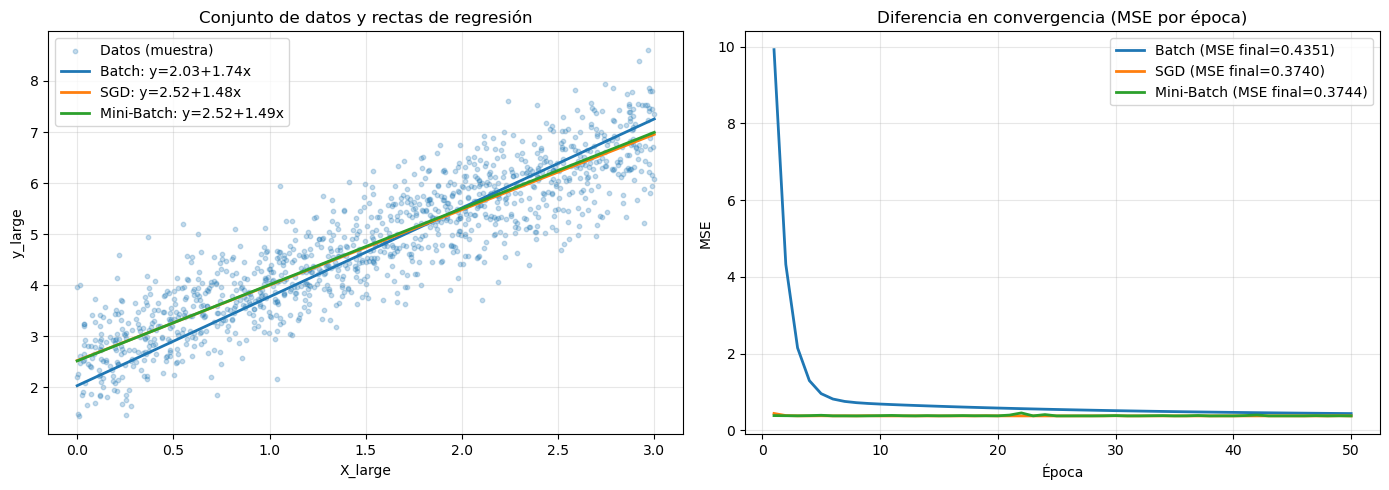

In [7]:
# Comparación visual de los 3 modelos sobre el conjunto grande
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Datos + rectas ajustadas ---
idx_plot = np.random.choice(len(X_large), size=1200, replace=False)
axes[0].scatter(X_large[idx_plot], y_large[idx_plot], s=10, alpha=0.25, label="Datos (muestra)")

x_grid = np.linspace(X_large.min(), X_large.max(), 300)
axes[0].plot(x_grid, b0_b + b1_b * x_grid, lw=2, label=f"Batch: y={b0_b:.2f}+{b1_b:.2f}x")
axes[0].plot(x_grid, b0_s + b1_s * x_grid, lw=2, label=f"SGD: y={b0_s:.2f}+{b1_s:.2f}x")
axes[0].plot(x_grid, b0_m + b1_m * x_grid, lw=2, label=f"Mini-Batch: y={b0_m:.2f}+{b1_m:.2f}x")

axes[0].set_title("Conjunto de datos y rectas de regresión")
axes[0].set_xlabel("X_large")
axes[0].set_ylabel("y_large")
axes[0].grid(alpha=0.3)
axes[0].legend()

# --- Panel 2: Evolución del costo ---
epochs_axis = np.arange(1, len(cost_batch) + 1)
axes[1].plot(epochs_axis, cost_batch, lw=2, label=f"Batch (MSE final={cost_batch[-1]:.4f})")
axes[1].plot(epochs_axis, cost_sgd, lw=2, label=f"SGD (MSE final={cost_sgd[-1]:.4f})")
axes[1].plot(epochs_axis, cost_mini, lw=2, label=f"Mini-Batch (MSE final={cost_mini[-1]:.4f})")

axes[1].set_title("Diferencia en convergencia (MSE por época)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MSE")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Benchmark Computacional de las Variantes

Aumentaremos artificialmente el tamaño del conjunto de datos a 100,000 registros para simular un escenario más cercano a la realidad industrial. Ejecutaremos 10 épocas de cada variante y mediremos el tiempo en segundos que le toma a la máquina procesar la información.

In [8]:
# Generamos un dataset masivo para evidenciar el cuello de botella
n_massive = 1000000
X_massive = 3 * np.random.rand(n_massive)
y_massive = 2.5 + 1.5 * X_massive + np.random.randn(n_massive) * 0.6

print(f"Dataset generado con {n_massive} observaciones.")
print("Iniciando benchmark de tiempos (10 épocas por variante)...\n")

# Parámetros base
epochs_bench = 10
lr_bench = 0.01

# --- 1. Batch GD ---
start_time = time.time()
# Usamos la función gd_variants definida en la celda anterior
_, _, _ = gd_variants(X_massive, y_massive, variant='batch', learning_rate=lr_bench, n_epochs=epochs_bench)
time_batch = time.time() - start_time
print(f"Batch GD        : {time_batch:.4f} segundos")

# --- 2. Stochastic GD (SGD) ---
start_time = time.time()
# Reducimos el learning rate para SGD por su alta varianza
_, _, _ = gd_variants(X_massive, y_massive, variant='stochastic', learning_rate=0.001, n_epochs=epochs_bench)
time_sgd = time.time() - start_time
print(f"Stochastic GD   : {time_sgd:.4f} segundos")

# --- 3. Mini-Batch GD ---
start_time = time.time()
_, _, _ = gd_variants(X_massive, y_massive, variant='minibatch', learning_rate=lr_bench, n_epochs=epochs_bench, batch_size=256)
time_mini = time.time() - start_time
print(f"Mini-Batch GD   : {time_mini:.4f} segundos")

Dataset generado con 1000000 observaciones.
Iniciando benchmark de tiempos (10 épocas por variante)...

Batch GD        : 0.2815 segundos
Stochastic GD   : 46.0943 segundos
Mini-Batch GD   : 0.3790 segundos


# Regresión Polinomial y el Dilema Sesgo-Varianza

## Limitaciones de la linealidad estricta

En las secciones anteriores optimizamos modelos bajo la presunción de que la relación entre las variables independientes y la variable dependiente es estrictamente lineal. Modelar relaciones exclusivamente como $\hat{y} = \beta_0 + \beta_1 x$ es insuficiente para dinámicas complejas donde existen curvaturas, umbrales o saturaciones.

## Expansión de la base polinomial

La Regresión Polinomial resuelve esta limitación proyectando las características originales a un espacio de mayor dimensionalidad mediante la adición de potencias de $x$:
$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + \dots + \beta_d x^d$$
El concepto matemático central que debe transmitirse a los estudiantes es que el modelo sigue siendo lineal respecto a los parámetros $\beta$. Al definir nuevas variables como $x_1 = x, x_2 = x^2, x_3 = x^3$, el sistema se transforma en una regresión lineal múltiple estándar:
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3$$

Dado que la linealidad paramétrica se mantiene, la función de costo sigue siendo convexa respecto a los pesos y podemos optimizarla utilizando los mismos algoritmos de Gradiente Descendiente discutidos en la Sección 2.

## Complejidad del modelo y Generalización

El hiperparámetro crítico en esta arquitectura es $d$, el grado del polinomio. Su selección introduce formalmente el concepto del dilema Sesgo-Varianza en el modelado predictivo:
* ***Underfitting (Sesgo alto)***: Ocurre cuando $d$ es demasiado bajo. El modelo carece de la capacidad representacional para capturar la estructura matemática subyacente de los datos.
* ***Overfitting (Varianza alta)***: Ocurre cuando $d$ es excesivamente alto. El modelo adquiere tanta flexibilidad que comienza a memorizar el ruido estocástico específico del conjunto de entrenamiento perdiendo toda capacidad de generalización ante datos no observados.
* ***Ajuste Óptimo***: El equilibrio donde el modelo captura la señal real minimizando el error esperado en el conjunto de prueba.

Para demostrar este fenómeno, implementaremos un pipeline de transformación de características y evaluación de métricas dividiendo rigurosamente los datos en conjuntos de entrenamiento y prueba.

### La Arquitectura de un Pipeline en Scikit-Learn
En el siguiente bloque de código vamos a introducir un objeto llamado Pipeline. Dado que es una de las herramientas arquitectónicas más importantes en la ingeniería de Machine Learning, es fundamental comprender su mecánica interna antes de ejecutar el modelo.

1. ***¿Qué es un Pipeline?***
En términos computacionales, un Pipeline  o cadena de montaje es una clase de scikit-learn que permite ensamblar secuencialmente múltiples pasos de preprocesamiento y un estimador final dentro de un único objeto unificado.

En lugar de aplicar transformaciones matemáticas a los datos de forma aislada y luego alimentar el modelo resultante, el Pipeline encapsula todo el proceso de principio a fin.

2. ***Mecánica Interna: La propagación de los datos***
Para que un Pipeline funcione, todos los pasos (excepto el último) deben ser "Transformadores", es decir, objetos que posean los métodos `fit()` y `transform()`. El último paso generalmente es un "Estimador", el cual posee los métodos `fit()` y `predict()`.

Cuando invocamos el comando `pipe.fit(X_train, y_train)`, ocurre la siguiente secuencia matemática en el fondo:
* *Paso 1 (PolynomialFeatures)*: El pipeline llama al método `fit_transform()` sobre X_train. Esto genera la matriz expandida con las potencias polinomiales.
* *Paso 2 (StandardScaler)*: La nueva matriz expandida pasa al siguiente eslabón. El pipeline llama a `fit_transform()` en el escalador. Aquí se calcula la media $\mu$ y la desviación estándar $\sigma$ de cada columna y se aplica la estandarización.
* *Paso 3 (LinearRegression)*: La matriz finalmente transformada llega al último eslabón. Al ser el estimador final, el pipeline solo llama al método `fit()`, ejecutando nuestro Gradiente Descendiente (o la solución OLS) para encontrar los parámetros $\beta$ óptimos.

Al momento de hacer inferencia invocando `pipe.predict(X_test)`, el pipeline asegura que los datos nuevos solo pasen por el método `transform()` de los pasos previos, garantizando consistencia matemática.

### Justificación del uso de pipes
Más allá de la limpieza y organización del código, el uso de Pipelines obedece a un principio estricto de seguridad en validación de modelos: evitar el ***Data Leakage (fuga de datos)***.

Si un ingeniero de datos aplica transformaciones estadísticas (como la estandarización) al dataset completo antes de realizar la partición entre entrenamiento y prueba, la media y la varianza calculadas contendrán información de los datos de prueba. Esto contamina el modelo, ***generando un sesgo optimista y métricas de rendimiento falsamente altas***.

El Pipeline aísla este proceso. Garantiza que cualquier cálculo estadístico necesario para el preprocesamiento se ejecute estricta y exclusivamente sobre los datos de entrenamiento durante la fase fit, aplicando esas mismas reglas estáticas a los datos nuevos durante la fase predict.

In [9]:
# Generación de datos: reducimos un poco n_poly para hacer el overfitting más evidente
np.random.seed(0)
n_poly = 50 
X_poly = np.sort(6 * np.random.rand(n_poly) - 3)
y_poly = 0.5 * X_poly**2 - X_poly + 2 + np.random.randn(n_poly) * 0.8

# Partición de datos
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y_poly, test_size=0.3, random_state=42
)

X_train_reshaped = X_train.reshape(-1, 1)
X_test_reshaped = X_test.reshape(-1, 1)

# Evaluación de grados: 1 (Underfitting), 2 (Óptimo), 20 (Overfitting Severo)
grados = [1, 2, 25]

print(f"{'Grado':<10} | {'MSE Train':<15} | {'MSE Test':<15}")
print("-" * 45)

modelos = {}

for grado in grados:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=grado, include_bias=False)),         # Expansión polinomial
        ('scaler', StandardScaler()),                                           # Estandarización de características
        ('lr', LinearRegression())                                              # Estimador Final
    ])
    
    pipe.fit(X_train_reshaped, y_train)
    modelos[grado] = pipe
    
    mse_train = mean_squared_error(y_train, pipe.predict(X_train_reshaped))
    mse_test = mean_squared_error(y_test, pipe.predict(X_test_reshaped))
    
    print(f"{grado:<10} | {mse_train:<15.4f} | {mse_test:<15.4f}")



Grado      | MSE Train       | MSE Test       
---------------------------------------------
1          | 3.3912          | 1.5103         
2          | 0.5630          | 0.4273         
25         | 0.1195          | 70427.7674     


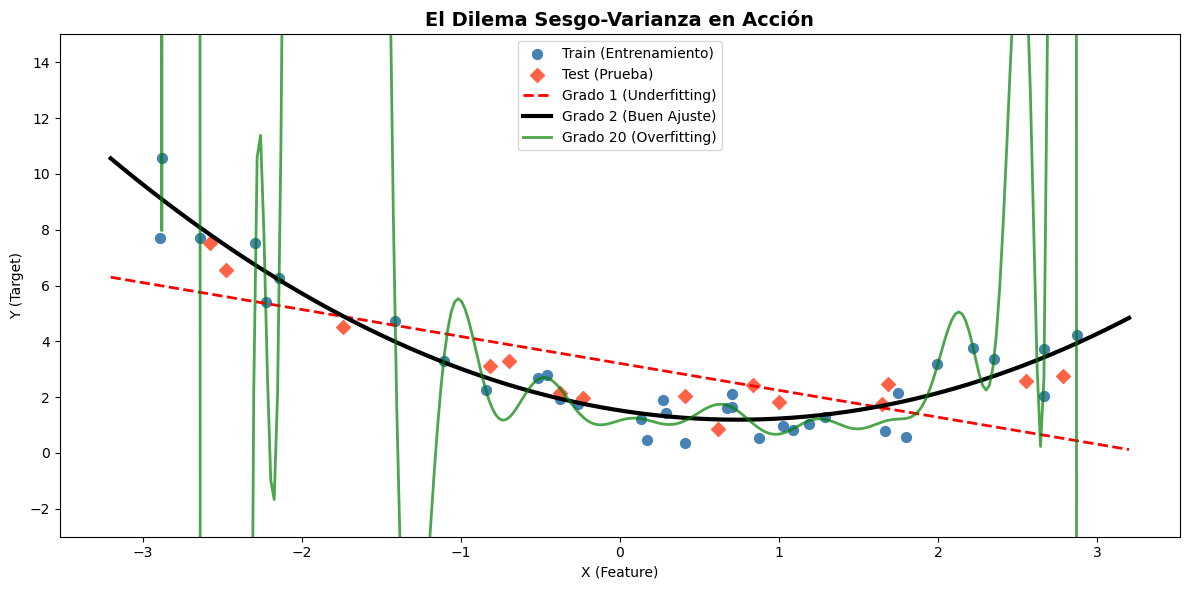

In [10]:
#  Vizualizacion de predicciones para los 3 modelos
X_line = np.linspace(-3.2, 3.2, 300).reshape(-1, 1)

plt.figure(figsize=(12, 6))
plt.scatter(X_train, y_train, color='steelblue', label='Train (Entrenamiento)', s=50)
plt.scatter(X_test, y_test, color='tomato', marker='D', label='Test (Prueba)', s=50)

# Graficamos las predicciones
plt.plot(X_line, modelos[1].predict(X_line), 'r--', linewidth=2, label='Grado 1 (Underfitting)')
plt.plot(X_line, modelos[2].predict(X_line), 'k-', linewidth=3, label='Grado 2 (Buen Ajuste)')
plt.plot(X_line, modelos[25].predict(X_line), 'g-', linewidth=2, alpha=0.7, label='Grado 20 (Overfitting)')

plt.ylim(-3, 15)
plt.title('El Dilema Sesgo-Varianza en Acción', fontsize=14, fontweight='bold')
plt.xlabel('X (Feature)')
plt.ylabel('Y (Target)')
plt.legend()
plt.tight_layout()
plt.show()

### Aplicación Práctica: Regresión Polinomial Multivariable

Antes de ejecutar el código, es vital comprender el cambio conceptual que ocurre al aplicar PolynomialFeatures a un conjunto de datos con múltiples variables. Hasta ahora, tratábamos cada característica como una columna independiente. Nuestro vector de entrada para un paciente era:
$$x = [age, bmi, children, smoker\_yes, \dots]$$

Al aplicar una transformación polinomial de grado 2, el modelo deja de ver variables aisladas. El transformador toma el vector original y calcula automáticamente todos los términos cuadráticos y todas las multiplicaciones cruzadas (interacciones) posibles, generando un nuevo y masivo vector de características expandido:
$$X_{poly} = [age, bmi, age^2, bmi^2, age \times bmi, age \times smoker\_yes, \dots]$$

Matemáticamente, para el algoritmo de Gradiente Descendiente (o OLS), esto no cambia nada. El modelo simplemente recibe una matriz $X_{poly}$ con muchas más columnas y asigna un peso $\beta$ a cada una. Sigue siendo un problema lineal: $$\hat{y} = X_{poly} \beta$$ 

La "magia" ocurre en el preprocesamiento, no en el estimador.

In [15]:
# 1. Carga y preparación base
df = pd.read_csv('data/insurance.csv')
df['log_charges'] = np.log1p(df['charges'])
df_mlr = pd.get_dummies(df, columns=['smoker', 'sex', 'region'], drop_first=True)

# Utilizamos las variables originales puras
features = ['age', 'bmi', 'children', 'smoker_yes', 'sex_male', 
            'region_northwest', 'region_southeast', 'region_southwest']

X = df_mlr[features]
y = df_mlr['log_charges']

# Partición rigurosa (80% Entrenamiento / 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Evaluación del Sesgo-Varianza: Grados 1 a 5
grados = list(range(1, 6))  
rmse_train_curve = []
rmse_test_curve = []


print(f"{'Arquitectura del Modelo':<30} | {'RMSE Train':<12} | {'RMSE Test':<12}")
print("-" * 60)

for grado in grados:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=grado, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    
    pipe.fit(X_train, y_train)
    
    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)
    
    # Calculamos RMSE para ambos conjuntos
    rmse_train_curve.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    rmse_test_curve.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))
    
    nombre_modelo = f"Polinomio (Grado {grado})"
    print(f"{nombre_modelo:<30} | {rmse_train_curve[-1]:<12.4f} | {rmse_test_curve[-1]:<12.4f}")

Arquitectura del Modelo        | RMSE Train   | RMSE Test   
------------------------------------------------------------
Polinomio (Grado 1)            | 0.4489       | 0.4189      
Polinomio (Grado 2)            | 0.3687       | 0.3490      
Polinomio (Grado 3)            | 0.3555       | 0.3600      
Polinomio (Grado 4)            | 0.3374       | 0.4058      
Polinomio (Grado 5)            | 0.3050       | 0.8081      


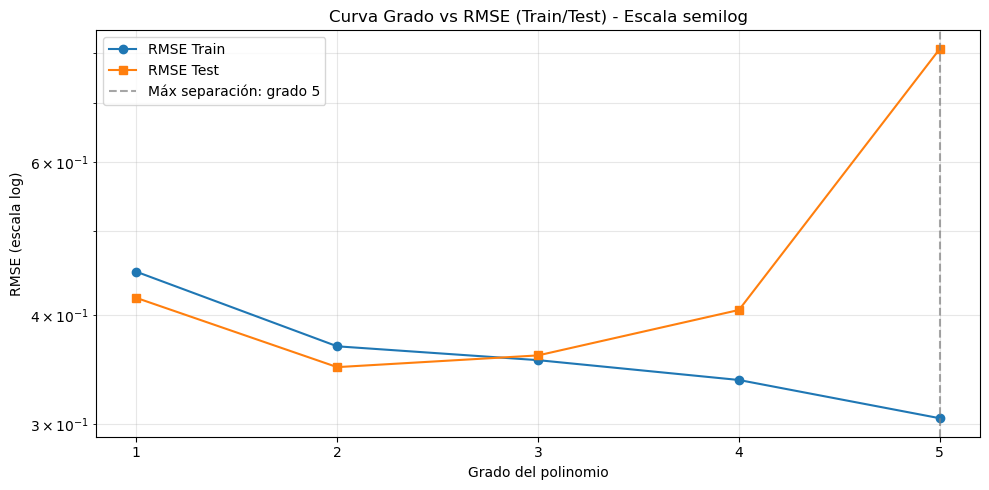

Mayor separación en grado 5:
RMSE Train = 0.3050
RMSE Test  = 0.8081
Gap        = 0.5031


In [16]:
# Grado donde más se separan ambas curvas
gap = np.array(rmse_test_curve) - np.array(rmse_train_curve)
idx_sep = int(np.argmax(gap))
grado_sep = grados[idx_sep]

plt.figure(figsize=(10, 5))
plt.semilogy(grados, rmse_train_curve, marker='o', label='RMSE Train')
plt.semilogy(grados, rmse_test_curve, marker='s', label='RMSE Test')
plt.axvline(grado_sep, color='gray', linestyle='--', alpha=0.7, label=f'Máx separación: grado {grado_sep}')

plt.title('Curva Grado vs RMSE (Train/Test) - Escala semilog')
plt.xlabel('Grado del polinomio')
plt.ylabel('RMSE (escala log)')
plt.xticks(grados)
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mayor separación en grado {grado_sep}:")
print(f"RMSE Train = {rmse_train_curve[idx_sep]:.4f}")
print(f"RMSE Test  = {rmse_test_curve[idx_sep]:.4f}")
print(f"Gap        = {gap[idx_sep]:.4f}")


=== Métricas del Modelo Cuadrático (grado 2) en USD ===
Train -> R2: 0.8157 | R2_adj: 0.8078 | RMSE: $5,158.04 | MAE: $2,689.10
Test  -> R2: 0.8547 | R2_adj: 0.8261 | RMSE: $4,749.04 | MAE: $2,404.51

Muestra Real vs Predicción (USD):
     y_real_usd    y_pred_usd  error_abs_usd
0    9095.06825  10792.178543    1697.110293
1    5272.17580   5508.365833     236.190033
2   29330.98315  27592.976792    1738.006358
3    9301.89355  10839.104034    1537.210484
4   33750.29180  24242.680880    9507.610920
5    4536.25900   4444.810252      91.448748
6    2117.33885   2481.057569     363.718719
7   14210.53595  15408.853725    1198.317775
8    3732.62510   3684.838671      47.786429
9   10264.44210  11990.590346    1726.148246
10  18259.21600  20360.138509    2100.922509
11   7256.72310   8565.269676    1308.546576


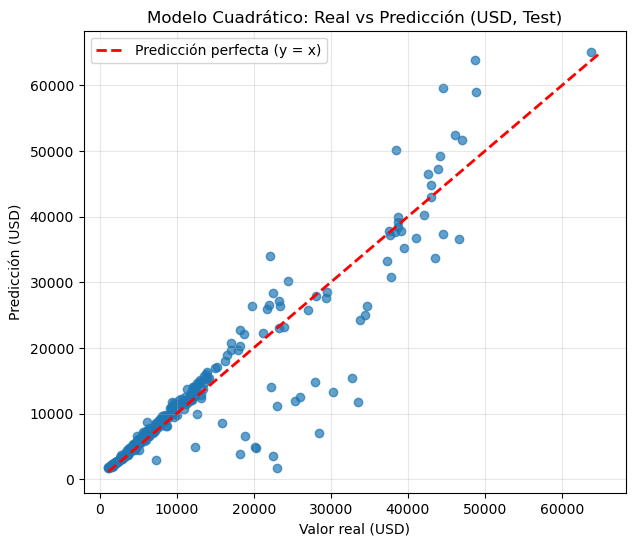

In [18]:
# Modelo cuadrático (grado 2) sobre el dataset de insurance
modelo_cuadratico = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

modelo_cuadratico.fit(X_train, y_train)

# Predicciones en escala log
y_pred_train_cuad = modelo_cuadratico.predict(X_train)
y_pred_test_cuad = modelo_cuadratico.predict(X_test)

# Convertir de log a dólares reales
y_train_usd = np.expm1(y_train)
y_test_usd = np.expm1(y_test)
y_pred_train_usd = np.expm1(y_pred_train_cuad)
y_pred_test_usd = np.expm1(y_pred_test_cuad)

# Métricas en dólares
r2_train_usd = r2_score(y_train_usd, y_pred_train_usd)
r2_test_usd = r2_score(y_test_usd, y_pred_test_usd)
rmse_train_usd = np.sqrt(mean_squared_error(y_train_usd, y_pred_train_usd))
rmse_test_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_test_usd))
mae_train_usd = np.mean(np.abs(y_train_usd - y_pred_train_usd))
mae_test_usd = np.mean(np.abs(y_test_usd - y_pred_test_usd))

# Número de variables efectivas p tras expansión polinomial
p = modelo_cuadratico.named_steps['poly'].transform(X_train).shape[1]
n_train = len(y_train_usd)
n_test = len(y_test_usd)

# R2 ajustado en dólares
r2_adj_train_usd = 1 - ((1 - r2_train_usd) * (n_train - 1) / (n_train - p - 1))
r2_adj_test_usd = 1 - ((1 - r2_test_usd) * (n_test - 1) / (n_test - p - 1))

print("=== Métricas del Modelo Cuadrático (grado 2) en USD ===")
print(f"Train -> R2: {r2_train_usd:.4f} | R2_adj: {r2_adj_train_usd:.4f} | RMSE: ${rmse_train_usd:,.2f} | MAE: ${mae_train_usd:,.2f}")
print(f"Test  -> R2: {r2_test_usd:.4f} | R2_adj: {r2_adj_test_usd:.4f} | RMSE: ${rmse_test_usd:,.2f} | MAE: ${mae_test_usd:,.2f}")

# Comparación real vs predicción (USD)
comparacion = pd.DataFrame({
    "y_real_usd": y_test_usd.values,
    "y_pred_usd": y_pred_test_usd,
    "error_abs_usd": np.abs(y_test_usd.values - y_pred_test_usd)
})
print("\nMuestra Real vs Predicción (USD):")
print(comparacion.head(12))

# Visual: Real vs Predicción en USD
plt.figure(figsize=(7, 6))
plt.scatter(y_test_usd, y_pred_test_usd, alpha=0.7)
lims = [min(y_test_usd.min(), y_pred_test_usd.min()), max(y_test_usd.max(), y_pred_test_usd.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta (y = x)')
plt.title("Modelo Cuadrático: Real vs Predicción (USD, Test)")
plt.xlabel("Valor real (USD)")
plt.ylabel("Predicción (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Transición a la Clasificación y la Función Sigmoide

## El límite matemático de la Regresión Lineal en espacios binarios

Hasta este punto de la sesión, hemos modelado variables continuas ($\hat{y} \in \mathbb{R}$), como el costo en dólares de un seguro médico. Sin embargo, una gran proporción de los problemas industriales requiere modelar variables objetivo discretas y binarias ($y \in \{0, 1\}$), como predecir si un paciente desarrollará una enfermedad, si una transacción es fraudulenta, o si un cliente abandonará un servicio (Churn).

Si intentamos aplicar una Regresión Lineal estándar ($\hat{y} = X\beta$) a un vector objetivo de ceros y unos, nos enfrentamos a una inconsistencia matemática fundamental. La línea recta se extenderá infinitamente en ambas direcciones, produciendo inevitablemente predicciones donde $\hat{y} < 0$ o $\hat{y} > 1$. Dado que en clasificación buscamos estimar la probabilidad de que una observación pertenezca a la clase positiva, una probabilidad negativa o superior al 100% carece de sentido axiomático.

## La Función Sigmoide como enlace probabilístico

Para resolver esta inconsistencia sin descartar la combinación lineal de características ($z = X\beta$) que nuestro modelo ya sabe calcular, introducimos una transformación no lineal que comprime cualquier valor real en el rango estricto $(0, 1)$. La función estándar para esta tarea es la Función Logística o Sigmoide:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
* ***Propiedades asintóticas***:
    * Cuando $z \to \infty$, $e^{-z} \to 0$, por lo tanto $\sigma(z) \to 1$.
    * Cuando $z \to -\infty$, $e^{-z} \to \infty$, por lo tanto $\sigma(z) \to 0$.
    * Cuando $z = 0$, $\sigma(z) = 0.5$ (El umbral de decisión natural).

La salida de esta función, $\hat{p} = \sigma(X\beta)$, se interpreta rigurosamente como la probabilidad condicional de que la clase sea 1, dado el vector de características $X$.

In [19]:
# Implementación matemática de la Función Sigmoide
def funcion_sigmoide(z):
    return 1 / (1 + np.exp(-z))

In [20]:
# Simulación de un problema de clasificación binaria (ej. Biomarcador vs Presencia de Enfermedad)
np.random.seed(42)
n_samples = 60

# Generamos dos distribuciones separadas para la clase 0 y la clase 1
X_biomarcador = np.concatenate([np.random.normal(30, 8, n_samples//2), 
                                np.random.normal(60, 8, n_samples//2)])
y_binario = np.concatenate([np.zeros(n_samples//2), np.ones(n_samples//2)])

X_reshaped = X_biomarcador.reshape(-1, 1)

# 2. Ajuste de Regresión Lineal Clásica (El enfoque incorrecto)
lr_invalido = LinearRegression()
lr_invalido.fit(X_reshaped, y_binario)

# Espacio de inferencia para trazar las curvas
x_rango = np.linspace(0, 90, 300).reshape(-1, 1)
y_pred_lineal = lr_invalido.predict(x_rango)

# Simulamos los pesos ajustados de una regresión logística para la demostración
# (z = beta_1 * x + beta_0)
z_valores = (x_rango - 45) * 0.15 
y_pred_sigmoide = funcion_sigmoide(z_valores)

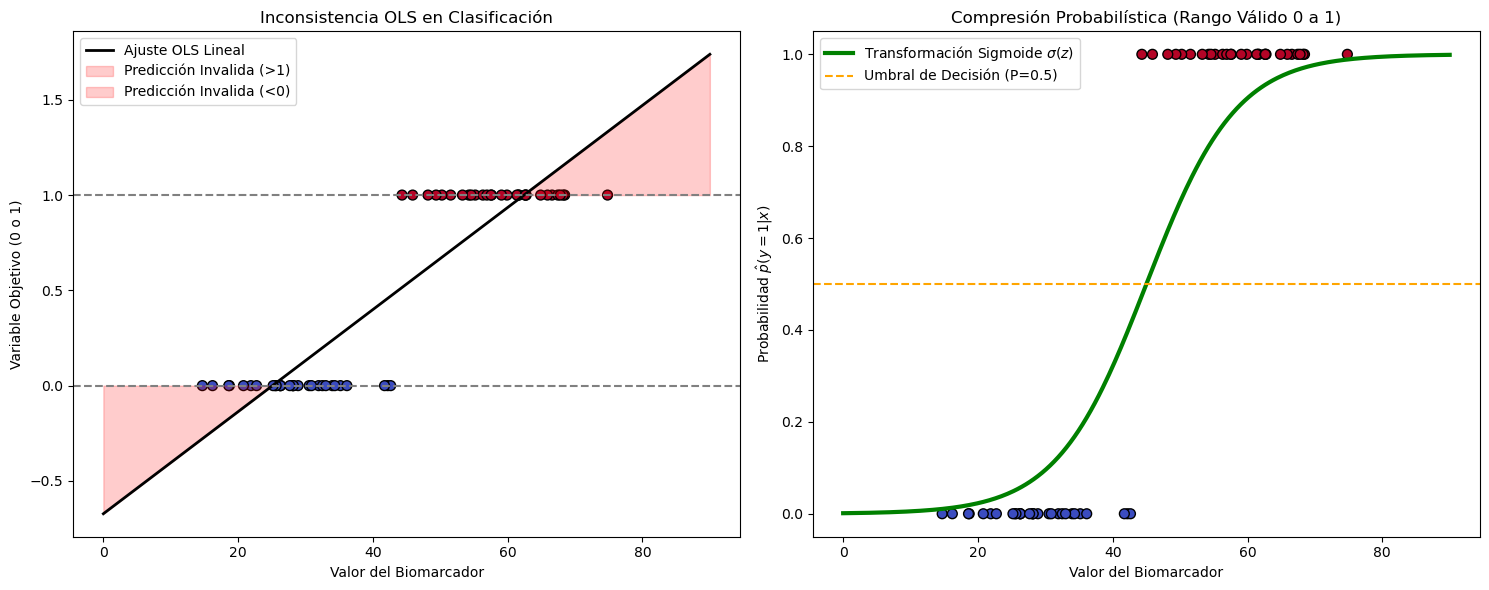

In [21]:
# 4. Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: El fallo de la Regresión Lineal
axes[0].scatter(X_biomarcador, y_binario, c=y_binario, cmap='coolwarm', edgecolors='k', s=50)
axes[0].plot(x_rango, y_pred_lineal, 'k-', linewidth=2, label='Ajuste OLS Lineal')
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].axhline(1, color='gray', linestyle='--')
axes[0].fill_between(x_rango.flatten(), y_pred_lineal, 1, where=(y_pred_lineal > 1), color='red', alpha=0.2, label='Predicción Invalida (>1)')
axes[0].fill_between(x_rango.flatten(), y_pred_lineal, 0, where=(y_pred_lineal < 0), color='red', alpha=0.2, label='Predicción Invalida (<0)')
axes[0].set_title('Inconsistencia OLS en Clasificación')
axes[0].set_xlabel('Valor del Biomarcador')
axes[0].set_ylabel('Variable Objetivo (0 o 1)')
axes[0].legend()

# Gráfico 2: La corrección de la Función Sigmoide
axes[1].scatter(X_biomarcador, y_binario, c=y_binario, cmap='coolwarm', edgecolors='k', s=50)
axes[1].plot(x_rango, y_pred_sigmoide, 'g-', linewidth=3, label='Transformación Sigmoide $\sigma(z)$')
axes[1].axhline(0.5, color='orange', linestyle='--', label='Umbral de Decisión (P=0.5)')
axes[1].set_title('Compresión Probabilística (Rango Válido 0 a 1)')
axes[1].set_xlabel('Valor del Biomarcador')
axes[1].set_ylabel('Probabilidad $\hat{p}(y=1|x)$')
axes[1].legend()

plt.tight_layout()
plt.show()

# Cierre 
Hoy hemos cubierto la evolución matemática de los modelos predictivos:

1. Transitó de la solución cerrada (OLS) ineficiente a un algoritmo de optimización iterativo escalable (Gradiente Descendiente).

2. Exploró estrategias de paralelización matricial (Mini-Batch).

3. Expandió la capacidad del modelo para ajustarse a dinámicas no lineales mediante combinaciones algebraicas (Regresión Polinomial).

4. Sentó las bases matemáticas para proyectar salidas continuas en espacios probabilísticos discretos (Función Sigmoide).

En la próxima sesión , tomaremos la función Log-Loss y aplicaremos el Gradiente Descendiente para construir nuestro primer clasificador formal: la Regresión Logística. Además, introduciremos las métricas de evaluación específicas para matrices de confusión (Precisión, Recall, F1-Score y Curvas ROC-AUC).